求得全局 rho* = 3.00000000
n= 1, sigma_post^2=12.500000, s_n^2=37.500000
n= 2, sigma_post^2=8.333333, s_n^2=33.333333
n= 3, sigma_post^2=6.250000, s_n^2=31.250000
n= 4, sigma_post^2=5.000000, s_n^2=30.000000
n= 5, sigma_post^2=4.166667, s_n^2=29.166667
n= 6, sigma_post^2=3.571429, s_n^2=28.571429
n= 7, sigma_post^2=3.125000, s_n^2=28.125000
n= 8, sigma_post^2=2.777778, s_n^2=27.777778
n= 9, sigma_post^2=2.500000, s_n^2=27.500000
n=10, sigma_post^2=2.272727, s_n^2=27.272727


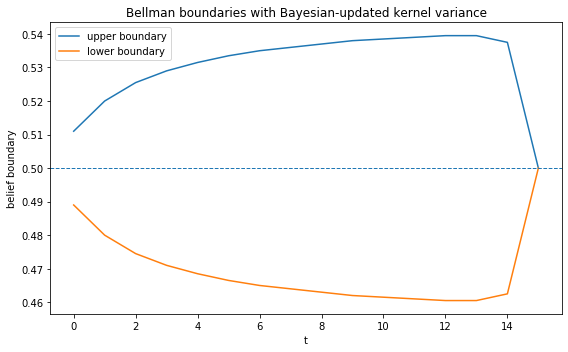

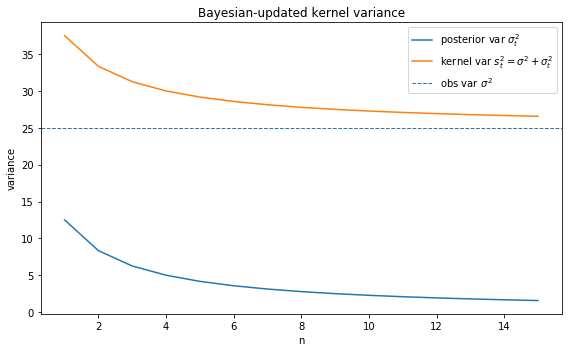

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. 参数设置
# ============================================================

mu0 = -2.2
mu1 =  2.2

# ------------------------------------------------------------
# 观测层固定方差 sigma^2
# 连续性信念中的后验方差更新：
#   sigma_post^2(t) = sigma0^2 * sigma^2 / (t * sigma0^2 + sigma^2)
# 改造后的转移核方差：
#   s_t^2 = sigma^2 + sigma_post^2(t)
# ------------------------------------------------------------

sigma2_obs = 25.0      # 原始观测噪声方差 sigma^2
sigma2_prior = 25.0    # 先验方差 sigma0^2，可自行调大/调小

T = 15
dt = 0.01
ti = 0.1
tp = 0.0

R11, R22 = 1.0, 1.0
R12, R21 = 0.0, 0.0

def c_of_t(t):
    return 10

def sigma2_post(n):
    """
    连续性信念中，第 n 步对应的后验方差：
        sigma_post^2(n) = sigma0^2 * sigma^2 / (n * sigma0^2 + sigma^2)
    这里 n >= 1
    """
    return (sigma2_prior * sigma2_obs) / (n * sigma2_prior + sigma2_obs)

def s2_kernel(n):
    """
    改造后的转移核方差：
        s_n^2 = sigma^2 + sigma_post^2(n)
    """
    return sigma2_obs + sigma2_post(n)

def s_kernel(n):
    return np.sqrt(s2_kernel(n))

# ============================================================
# 2. 数值离散
# ============================================================

eps = 1e-4
Nb = 2001
b_grid = np.linspace(eps, 1.0 - eps, Nb)

# x 的积分范围按“最大核方差”来定
sigma_max = s_kernel(1)
Nx = 3201
x_min = min(mu0, mu1) - 8 * sigma_max
x_max = max(mu0, mu1) + 8 * sigma_max
x_grid = np.linspace(x_min, x_max, Nx)
dx = x_grid[1] - x_grid[0]

b0 = 0.5
idx_b0 = np.argmin(np.abs(b_grid - b0))

# ============================================================
# 3. 基础函数
# ============================================================

def normal_pdf(x, mu, sigma):
    return (1.0 / (np.sqrt(2.0 * np.pi) * sigma)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def bayes_update(b, f0, f1):
    """
    b = P(H1 | history)
    观察到 x 后：
        b' = f1(x) b / [f1(x) b + f0(x) (1-b)]
    """
    denom = f1 * b + f0 * (1.0 - b)
    return (f1 * b) / np.maximum(denom, 1e-300)

def stop_values(b, rho):
    stop_h1 = b * R11 + (1.0 - b) * R12 - ti * rho
    stop_h2 = (1.0 - b) * R22 + b * R21 - ti * rho
    return stop_h1, stop_h2

# ============================================================
# 4. 预计算“时变转移核”
# ============================================================
# 新转移核：
#   f1^(t)(x) = N(mu1, s_t^2)
#   f0^(t)(x) = N(mu0, s_t^2)
#   pred(x|b_t) = b_t f1^(t)(x) + (1-b_t) f0^(t)(x)
#   b_{t+1} = f1 b_t / (f1 b_t + f0 (1-b_t))
# ============================================================

b_next_tables = np.empty((T, Nb, Nx))
pred_pdf_tables = np.empty((T, Nb, Nx))

for t in range(T):
    n = t + 1
    sig = s_kernel(n)

    f0_x_t = normal_pdf(x_grid, mu0, sig)
    f1_x_t = normal_pdf(x_grid, mu1, sig)

    for i, b in enumerate(b_grid):
        pred_pdf = b * f1_x_t + (1.0 - b) * f0_x_t
        b_next = bayes_update(b, f0_x_t, f1_x_t)

        pred_pdf_tables[t, i, :] = pred_pdf
        b_next_tables[t, i, :] = np.clip(b_next, eps, 1.0 - eps)

# ============================================================
# 5. 时变继续价值
# ============================================================

def expected_continue_value(V_next, t):
    out = np.empty(Nb)

    for i in range(Nb):
        b_next = b_next_tables[t, i]
        pred_pdf = pred_pdf_tables[t, i]

        V_interp = np.interp(b_next, b_grid, V_next)
        out[i] = np.sum(V_interp * pred_pdf) * dx

    return out

# ============================================================
# 6. 给定 rho 的 Bellman 反向迭代
# ============================================================

def backward_bellman_given_rho(rho, return_all=False):
    V = np.zeros((T + 1, Nb))
    policy = np.zeros((T + 1, Nb), dtype=int)
    # 0 = choose H2, 1 = wait, 2 = choose H1

    stop_h1_T, stop_h2_T = stop_values(b_grid, rho)
    V[T, :] = np.maximum(stop_h1_T, stop_h2_T)
    policy[T, :] = np.where(stop_h1_T >= stop_h2_T, 2, 0)

    for t in range(T - 1, -1, -1):
        stop_h1, stop_h2 = stop_values(b_grid, rho)
        stop_best = np.maximum(stop_h1, stop_h2)

        cont = expected_continue_value(V[t + 1, :], t) - c_of_t(t) * dt - rho * dt

        V[t, :] = np.maximum(stop_best, cont)

        choose_wait = cont > stop_best
        choose_h1 = (stop_h1 >= stop_h2) & (~choose_wait)
        choose_h2 = (stop_h2 > stop_h1) & (~choose_wait)

        policy[t, choose_wait] = 1
        policy[t, choose_h1] = 2
        policy[t, choose_h2] = 0

    if return_all:
        return V, policy
    return V[0, idx_b0]

# ============================================================
# 7. 求全局 rho
# ============================================================

def find_global_rho(rho_lo=-2.0, rho_hi=2.0, tol=1e-6, max_iter=80):
    f_lo = backward_bellman_given_rho(rho_lo)
    f_hi = backward_bellman_given_rho(rho_hi)

    expand_count = 0
    while f_lo * f_hi > 0 and expand_count < 30:
        width = rho_hi - rho_lo
        rho_lo -= width
        rho_hi += width
        f_lo = backward_bellman_given_rho(rho_lo)
        f_hi = backward_bellman_given_rho(rho_hi)
        expand_count += 1

    if f_lo * f_hi > 0:
        raise RuntimeError(
            f"找不到包含根的 rho 区间: "
            f"rho_lo={rho_lo}, V0={f_lo}, rho_hi={rho_hi}, V0={f_hi}"
        )

    for _ in range(max_iter):
        rho_mid = 0.5 * (rho_lo + rho_hi)
        f_mid = backward_bellman_given_rho(rho_mid)

        if abs(f_mid) < tol:
            return rho_mid

        if f_lo * f_mid <= 0:
            rho_hi = rho_mid
            f_hi = f_mid
        else:
            rho_lo = rho_mid
            f_lo = f_mid

    return 0.5 * (rho_lo + rho_hi)

# ============================================================
# 8. 边界提取
# ============================================================

def extract_upper_boundary(policy):
    upper_boundary = np.empty(T + 1)
    half_mask = b_grid >= 0.5
    b_half = b_grid[half_mask]

    for t in range(T + 1):
        p_half = policy[t, half_mask]
        wait_idx = np.where(p_half == 1)[0]

        if len(wait_idx) == 0:
            upper_boundary[t] = 0.5
        else:
            upper_boundary[t] = b_half[wait_idx[-1]]

    return upper_boundary

# ============================================================
# 9. 主程序
# ============================================================

# rho_star = find_global_rho()
rho_star = 3.00
V, policy = backward_bellman_given_rho(rho_star, return_all=True)
upper_boundary = extract_upper_boundary(policy)
lower_boundary = 1.0 - upper_boundary

print(f"求得全局 rho* = {rho_star:.8f}")
# print(f"检查 V_0(1/2) = {V[0, idx_b0]:.8e}")

# print("\n前10步：后验方差 sigma_post^2(n)、核方差 s_n^2")
for n in range(1, 11):
    print(
        f"n={n:2d}, "
        f"sigma_post^2={sigma2_post(n):.6f}, "
        f"s_n^2={s2_kernel(n):.6f}"
    )

# ============================================================
# 10. 可视化
# ============================================================

t_grid = np.arange(T + 1)

plt.figure(figsize=(8, 5))
plt.plot(t_grid, upper_boundary, label='upper boundary')
plt.plot(t_grid, lower_boundary, label='lower boundary')
plt.axhline(0.5, linestyle='--', linewidth=1)
plt.xlabel('t')
plt.ylabel('belief boundary')
plt.title('Bellman boundaries with Bayesian-updated kernel variance')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sigma_post_seq = np.array([sigma2_post(n) for n in range(1, T + 1)])
kernel_var_seq = np.array([s2_kernel(n) for n in range(1, T + 1)])
plt.plot(np.arange(1, T + 1), sigma_post_seq, label=r'posterior var $\sigma_t^2$')
plt.plot(np.arange(1, T + 1), kernel_var_seq, label=r'kernel var $s_t^2=\sigma^2+\sigma_t^2$')
plt.axhline(sigma2_obs, linestyle='--', linewidth=1, label=r'obs var $\sigma^2$')
plt.xlabel('n')
plt.ylabel('variance')
plt.title(r'Bayesian-updated kernel variance')
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
V

array([[0.6999   , 0.6994001, 0.6989002, ..., 0.6989002, 0.6994001,
        0.6999   ],
       [0.6999   , 0.6994001, 0.6989002, ..., 0.6989002, 0.6994001,
        0.6999   ],
       [0.6999   , 0.6994001, 0.6989002, ..., 0.6989002, 0.6994001,
        0.6999   ],
       ...,
       [0.6999   , 0.6994001, 0.6989002, ..., 0.6989002, 0.6994001,
        0.6999   ],
       [0.6999   , 0.6994001, 0.6989002, ..., 0.6989002, 0.6994001,
        0.6999   ],
       [0.6999   , 0.6994001, 0.6989002, ..., 0.6989002, 0.6994001,
        0.6999   ]])